# Basic Usage

In [1]:
%load_ext autoreload
%autoreload 2
    
%matplotlib widget

from pySEA.sea_eco.io import collect_swift_file
from pySEA.sea_eco.io import swift_to_sea_metadata

import numpy as np
from pprint import pprint

## Metadata class
Check that metadata can be read from all of the test files and converted to the GeneralMetada class

In [2]:
from pySEA.sea_eco.architecture.base_structure_numpy import GeneralMetadata

GeneralMetadata()

In [3]:
meta_dict = {'General': {'title': 'Some Title', 
                         'uuid': 'some UUID'}, 
             'Instrument': {'beam_energy':60E3, 
                            'Detectors': {'Dectris_ELA': {'name':'Dectris ELA','exposure':0.01}}, 
                            'Scan': {'scan_uuid': 'XXXXXXXX0000000', 'scan_rotation':0, 'dwell_time':4.0},
                            },
             'some meta': 1.}
meta = GeneralMetadata(meta_dict)
meta

├── General
|  ├── title: Some Title
|  └── uuid: some UUID
├── Instrument
|  ├── beam_energy: 60000.0
|  ├── Detectors
|  |  └── Dectris_ELA
|  |     ├── name: Dectris ELA
|  |     └── exposure: 0.01
|  └── Scan
|     ├── scan_uuid: XXXXXXXX0000000
|     ├── scan_rotation: 0
|     └── dwell_time: 4.0
└── some meta: 1.0

In [4]:
meta.to_sea('./meta.sea')

## Dimensions and Dimension Class
Demonstrate Dimension creation from kwargs. <br />
Demonstrate Dimensions and Dimension handling from metadata

In [5]:
from pySEA.sea_eco.architecture.base_structure_numpy import Dimension, Dimensions

Dimension().show_tree()
Dimensions().show_tree()

C:\Users\e81\Documents\GitHub\sea-eco\src\pySEA\sea_eco\architecture\base_structure_numpy.py:689: UserWarning: size is None.
  if key not in checks.items(): warn(f'{key} is None.')
C:\Users\e81\Documents\GitHub\sea-eco\src\pySEA\sea_eco\architecture\base_structure_numpy.py:689: UserWarning: offset is None.
  if key not in checks.items(): warn(f'{key} is None.')
C:\Users\e81\Documents\GitHub\sea-eco\src\pySEA\sea_eco\architecture\base_structure_numpy.py:689: UserWarning: scale is None.
  if key not in checks.items(): warn(f'{key} is None.')


### Creating dimension from kwargs

Creation of an 1D-dimension from atributes

In [6]:
kwarg_dict = dict(name='x', space='position', units='nm',
                  size=5, offset=-10, scale=10)
dimension = Dimension(**kwarg_dict)

print(f'Dict:            {kwarg_dict}')
print(f'Dimension (str):      {dimension}')
print(f'Dimension (__repr__): {dimension.__repr__()}')
print(f'Shape:           {dimension.values.shape}')
dimension.show_tree()


Dict:            {'name': 'x', 'space': 'position', 'units': 'nm', 'size': 5, 'offset': -10, 'scale': 10}
Dimension (str):      x-dimension
Dimension (__repr__): <Dimension name:x ndim:1 size:5>
Shape:           (5,)


In [7]:
kwarg_dict = dict(name='xy', space='position', units='nm',
                  size=5, offset=[-1,-10], scale=[1,10])
dimension = Dimension(**kwarg_dict)
print(f'Dict:                 {kwarg_dict}')
print(f'Dimension (str):      {dimension}')
print(f'Dimension (__repr__): {dimension.__repr__()}')
print(f'Shape:                {dimension.values.shape}')
dimension.show_tree()


Dict:                 {'name': 'xy', 'space': 'position', 'units': 'nm', 'size': 5, 'offset': [-1, -10], 'scale': [1, 10]}
Dimension (str):      xy-dimension
Dimension (__repr__): <Dimension name:xy ndim:2 size:5>
Shape:                (2, 5)


In [8]:
array = np.array([np.arange(11),np.arange(11)*10])
kwarg_dict = dict(name=['x','y'], space='position', units='nm',
                  values=array)

dimension = Dimension(**kwarg_dict)
print(f'Dict:')
pprint(kwarg_dict, indent=5)
print(f'Dimension (str):      {dimension}')
print(f'Dimension (__repr__): {dimension.__repr__()}')
print(f'Shape:                {dimension.values.shape}')
dimension.show_tree()

Dict:
{    'name': ['x', 'y'],
     'space': 'position',
     'units': 'nm',
     'values': array([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10],
       [  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100]])}
Dimension (str):      (x, y)-dimension
Dimension (__repr__): <Dimension name:(x, y) ndim:2 size:None>
Shape:                (2, 11)


In [9]:
dimension.to_sea('./dimension.sea')

### Creating Dimensions from kwargs

The Dimension class can be created by providing a list of dictionarys representing the dimensions

In [10]:
kwarg_dict0 = dict(name='t', space='temporal', units='frame',
                  size=5, offset=0, scale=1)
kwarg_dict1 = dict(name='y', space='position', units='nm',
                  size=11, offset=-60, scale=10)
kwarg_dict2 = dict(name='x', space='position', units='nm',
                  size=21, offset=-60, scale=5)
kwarg_dict3 = dict(name='E', space='spectral', units='eV',
                  size=512, offset=-1.6, scale=0.1)

kwarg_dicts = [kwarg_dict0, kwarg_dict1, kwarg_dict2, kwarg_dict3]
dimensions = Dimensions(kwarg_dicts)

dimensions.show_tree()

The Dimensions class can also be initialized by supplying dimensions

In [11]:
dimensions = Dimensions([Dimension(kws) for kws in kwarg_dicts], nav_dimensions=[1,2], sig_dimensions=[3])
dimensions.show_tree()

Dimensions can also be added after initialization using `dimensions.add_dimension()`. This is helpful for creating and modifying Dimensions when designing analysis workflows. However, one should be carefull as this could create mismatch with data dimensions within a class.

In [12]:
dimensions.to_sea('./dimensions.sea')

### Indexing Dimension(s)

A dimensions values can be indexed directly for convenience.

In [13]:
dimension = dimensions['x'].deepcopy()
dimension[0:300.]

array([-60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10,  -5,   0,
         5,  10,  15,  20,  25,  30,  35])

Dimensions can be indexed by name or integerr

In [14]:
print(dimensions.get_names())
display(dimensions[0])
display(dimensions['x'])

['t', 'y', 'x', 'E']


<Dimension name:t ndim:1 size:5>

<Dimension name:x ndim:1 size:21>

## Signal

In [15]:
from pySEA.sea_eco.architecture.base_structure_numpy import Signal

Signal()

<Signal name="Signal" signal_type=None dimensions_domain=local>

In [16]:
import matplotlib.pyplot as plt
from pySEA.sea_eco.models.components.gaussians import Gaussian1D, GaussianND, gaussian_nd

# Create a ZLP
e = dimensions.dimensions[-1].values
zlp = Gaussian1D(A=1E6, mu=0 , sigma=0.1).evaluate(e)
# fig, ax = plt.subplots()
# ax.plot(e, zlp)

# Create a vacuum probe that decreases in intensity with time
dims_n = [dim.size for dim in dimensions.dimensions]
scale = np.linspace(100,1E-2,dims_n[0])[:, *(None,)*(len(dims_n)-1)]
vac = scale * np.tile(zlp, (dims_n[:-1]+[1]))
print(f'Size of dimensions: {dims_n}')
print(f'Shape of vacuum probe: {vac.shape}')

# Create loss function
yxe = np.stack(np.meshgrid(*[dim.values for dim in dimensions.dimensions[1:]], indexing='ij'), axis=-1)
# loss = gaussian_nd(yxe, A=-1E4, mu=[10,750,0] , sigma=np.diag([60,3000, 0.1])) + \
#     gaussian_nd(yxe, A=1E3, mu=[10,750,15] , sigma=np.diag([60,3000, 1]))
mu = np.array([0,0,0])
sigma = [30/2.355,30/2.355, 0.1]
loss = GaussianND(A=-1E5, mu=mu , sigma=sigma).evaluate(yxe) + \
    GaussianND(A=1E3, mu=mu+[0,0,15] , sigma=sigma*np.array([1,1,10])).evaluate(yxe)
loss = scale * loss[None,:]
print(f'Shape of loss: {loss.shape}')
# fig, axs = plt.subplots(ncols=2)
# axs[0].imshow(loss[...,100:].sum((0,-1)), aspect='equal',
#               extent=dimensions['x'].get_extent()+dimensions['y'].get_extent()[::-1]
#               )
# axs[0].set_xlabel('x')
# axs[0].set_ylabel('y')
# axs[1].imshow(loss[0,dimensions['y'].size//2],
#               aspect='auto',
#               extent=dimensions['E'].get_extent()+dimensions['x'].get_extent()[::-1]
#               )
# axs[1].set_xlabel('E')
# axs[1].set_ylabel('x')
# fig, ax = plt.subplots()
# ax.plot(e, loss[0,dimensions['y'].size//2,dimensions['x'].size//2])

# Combine probe, loss, and noise
noise = np.random.random(dims_n)*0.1
sig_data = vac+loss + noise
# fig, axs = plt.subplots(ncols=4)
# axs[0].imshow(sig_data[0,...].sum(-1), aspect='auto')
# axs[1].imshow(sig_data[0,...,:100].sum(-1), aspect='auto')
# axs[2].imshow(sig_data[0,...,100:].sum(-1), aspect='auto')
# axs[3].imshow(sig_data[0,0], aspect='auto')
# for ax,l in zip(axs, ['total','ZLF','ELF','xE']):
#     ax.set_title(l)

Size of dimensions: [5, 11, 21, 512]
Shape of vacuum probe: (5, 11, 21, 512)
Shape of loss: (5, 11, 21, 512)


In [17]:
signal = Signal(sig_data, dimensions=dimensions, metadata=meta,
                 original_metadata=GeneralMetadata({'source':'simulated data'})
                 )
signal.show_tree()

In [18]:
signal.to_sea('./signal.sea')

### Singal Indexing

Demonstrate indexing

In [19]:
signal.dimensions

<Dimensions ndim:4 dimensions:[t, y, x, E]>

In [20]:
s = signal[0,-50.:30.:20.]
print(signal.dimensions.dimensions)
print(s.dimensions.dimensions)
print(signal.data.shape, s.data.shape)
s.dimensions

[<Dimension name:t ndim:1 size:5>, <Dimension name:y ndim:1 size:11>, <Dimension name:x ndim:1 size:21>, <Dimension name:E ndim:1 size:512>]
[<Dimension name:y ndim:1 size:4>, <Dimension name:x ndim:1 size:21>, <Dimension name:E ndim:1 size:512>]
(5, 11, 21, 512) (4, 21, 512)


<Dimensions ndim:3 dimensions:[y, x, E]>

In [21]:
print(f'original shape: {signal.data.shape}')
print(f'index [0,1:4] shape: {signal[0,1:4].data.shape}')
print(f'index [0,4.:36.:8.] shape: {signal[0,-10.:30.:8.].data.shape}')
print(f'index [0,...,-1] shape: {signal[0,...,-1].data.shape}')

original shape: (5, 11, 21, 512)
index [0,1:4] shape: (3, 21, 512)
index [0,4.:36.:8.] shape: (4, 21, 512)
index [0,...,-1] shape: (11, 21)


### Funciton wrapping

If the funciton collapses the signal to 0-D then a value is returned not a signal

In [22]:
s = np.sum(signal)
print(f'{signal.dimensions} to {s}')

<Dimensions ndim:4 dimensions:[t, y, x, E]> to 576408168889.7246


Integer and tuple indexing are both valid

In [23]:
s = np.sum(signal, axis=1)
print(s)
print(f'{signal.dimensions}({signal.data.shape}) \nto {s.dimensions}({s.data.shape})')
print()

s = np.sum(signal, axis=(1,2))
print(f'{signal.dimensions}({signal.data.shape}) \nto {s.dimensions}({s.data.shape})')

Signal-signal
<Dimensions ndim:4 dimensions:[t, y, x, E]>((5, 11, 21, 512)) 
to <Dimensions ndim:3 dimensions:[t, x, E]>((5, 21, 512))

<Dimensions ndim:4 dimensions:[t, y, x, E]>((5, 11, 21, 512)) 
to <Dimensions ndim:2 dimensions:[t, E]>((5, 512))


Both dimension names and reverese indexing are supported

In [24]:
s = np.sum(signal, axis=('t',-1))
print(f'{signal.dimensions}({signal.data.shape}) \nto {s.dimensions}({s.data.shape})')

<Dimensions ndim:4 dimensions:[t, y, x, E]>((5, 11, 21, 512)) 
to <Dimensions ndim:2 dimensions:[y, x]>((11, 21))


### Other

The signals can be unfolded to iterate over axes.

In [25]:
state = signal.unfold_axes(keep_axes=['x','E'])
state, signal.data.shape

({'other_axes': [0, 1],
  'keep_axes': [2, 3],
  'permute': [0, 1, 2, 3],
  'original_shape': (5, 11, 21, 512),
  'other_shape': (5, 11),
  'kept_shape': (21, 512)},
 (55, 21, 512))

They can then be refolded

In [26]:
signal.fold_axes()
signal.data.shape

(5, 11, 21, 512)

## SignalSet


In [27]:
from pySEA.sea_eco.architecture.base_structure_numpy import SignalSet, AcquisitionSet

display('SignalSet')
SignalSet().show_tree()
display('AquisitionSet')
AcquisitionSet().show_tree()

'SignalSet'

'AquisitionSet'

In [28]:
adf = signal.deepcopy_with_reduced_data_dim(np.mean(vac, axis=-1), keep_dim=(0,1,2))
adf.metadata.Instrument.Detectors.update_from_dict({'ADF':{'exposure':10.}})
del adf.metadata.Instrument.Detectors.Dectris_ELA

abf = signal.deepcopy_with_reduced_data_dim(np.sum(signal[...,:5.], axis=-1), keep_dim=(0,1,2))
abf.metadata.Instrument.Detectors.update_from_dict({'ABF':{'exposure':10.}})
del abf.metadata.Instrument.Detectors.Dectris_ELA

In [29]:
signals = [adf, abf, signal]
names = ['HAADF', 'vBF', 'SI']
for signal,name in zip(signals,names): signal.name=name
print('Signals in set:')
pprint(signals)

signal_set = SignalSet(signals=signals, main_signal=-1)
signal_set.show_tree()

Signals in set:
[<Signal name="HAADF" signal_type=None dimensions_domain=local>,
 <Signal name="vBF" signal_type=None dimensions_domain=local>,
 <Signal name="SI" signal_type=None dimensions_domain=local>]


In [30]:
signals = [adf, abf, signal]
names = ['HAADF', 'vBF', 'SI']

acquisition_set = AcquisitionSet(signals=signals, main_signal=-1)
acquisition_set.show_tree()

## Save and load

In [31]:
acquisition_set.to_sea('./acquisition_set.sea')

In [32]:
acquisition_set_loaded = AcquisitionSet()
acquisition_set_loaded.from_sea('./acquisition_set.sea')
acquisition_set_loaded.show_tree()

## Plotting

In [33]:
import matplotlib.pyplot as plt

### Matplotlib figures

<Dimensions ndim:4 dimensions:[t, y, x, E]>


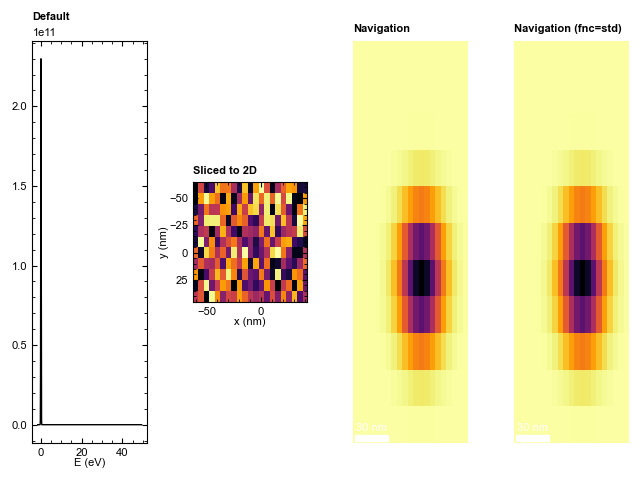

In [34]:
print(signal.dimensions)

fig,axs=plt.subplots(ncols=4)
signal.show(ax=axs[0], title='Default')
signal[0,...,1].show(ax=axs[1], title='Sliced to 2D', ticks_and_labels='on', scale_bar=False)
signal.show(ax=axs[2], dims='nav', title='Navigation', aspect='auto')
signal.show(ax=axs[3], dims='nav', title='Navigation (fnc=std)', aspect='auto', fnc=np.std)
fig.tight_layout()


### Interactive

In [35]:
from pySEA.sea_eco._plotting.interactive.ipywidget import interactive_signal_plot

The default note book interactive plotting provides navigator display dropdowns and signal dropdowns to select what will be plotted. Navigator sliders appear for all non-signal axes to aid in navigation.

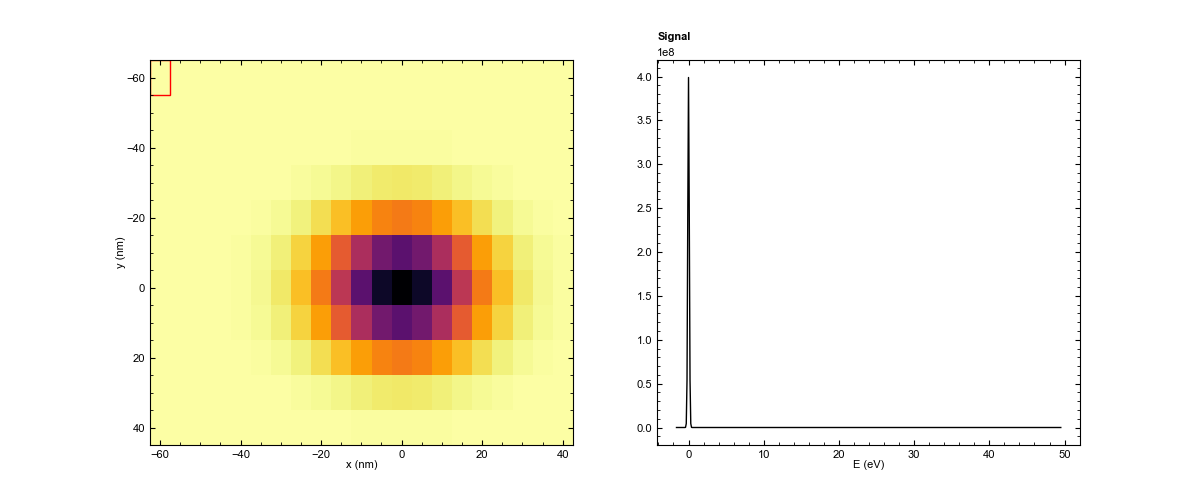

In [36]:
interactive_signal_plot(signal)

The initial plotting dimension can also be provided and the selector turned off. Integer, negative, and named dimension refferences are all supported.

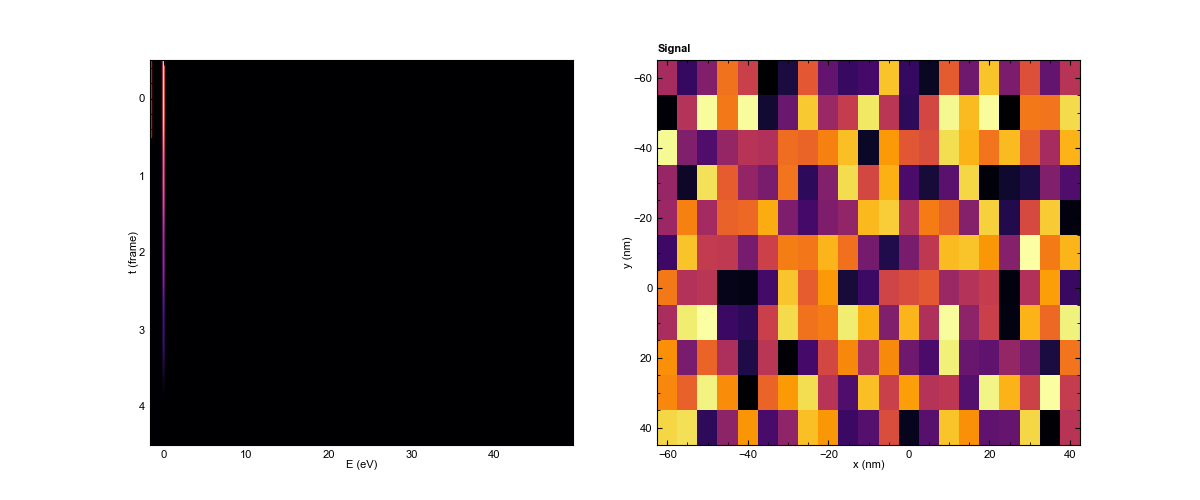

In [37]:
interactive_signal_plot(signal,
                      nav_dimensions=[0, -1],
                      sig_dimensions=['y','x'],
                      show_dimension_selector=False)

The function used to collapse navigation axes can be supplied.

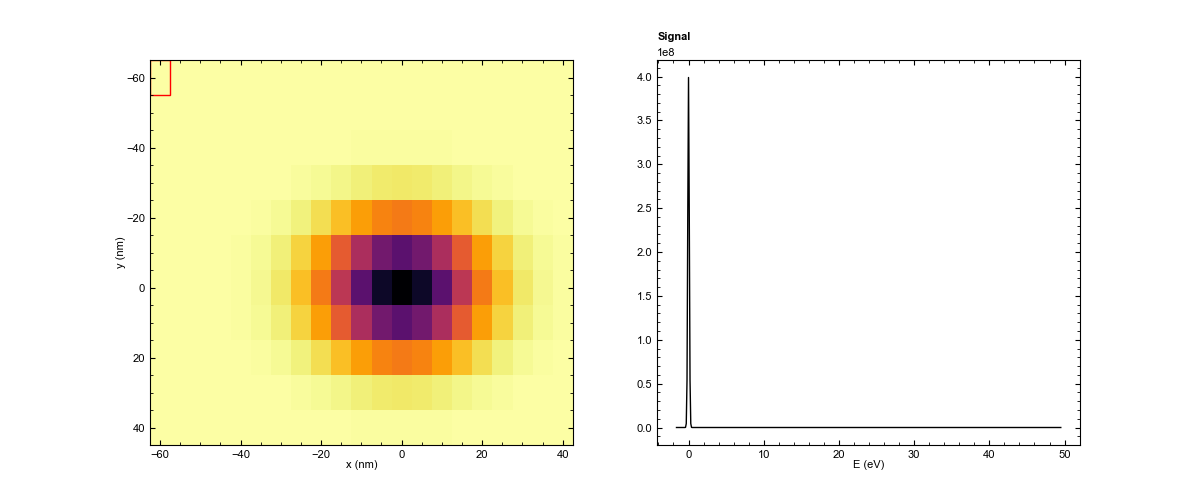

In [38]:
interactive_signal_plot(signal, nav_fnc=np.std)